# Import Libraries

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Subset

# Read Dataset and Split

In [3]:
mean = [0.4914, 0.4822, 0.4465]
std  = [0.2023, 0.1994, 0.2010]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

train_dataset = datasets.CIFAR10('./data', transform=transform, download=True, train=True)
test_dataset = datasets.CIFAR10('./data', transform=transform, download=True, train=False)

In [4]:
ind = list(range(len(train_dataset)))
np.random.shuffle(ind)
split = int(0.1 * len(train_dataset))
train_ind, val_ind = ind[split:], ind[:split]

In [5]:
train_subset = Subset(train_dataset, train_ind)
val_subset = Subset(train_dataset, val_ind)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False)

# Show Example of Dataset

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.5574567].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3321412..2.734221].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.024918..2.7537313].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.162586..2.107005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.6171591].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3199205..2.4559333].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2739866..2

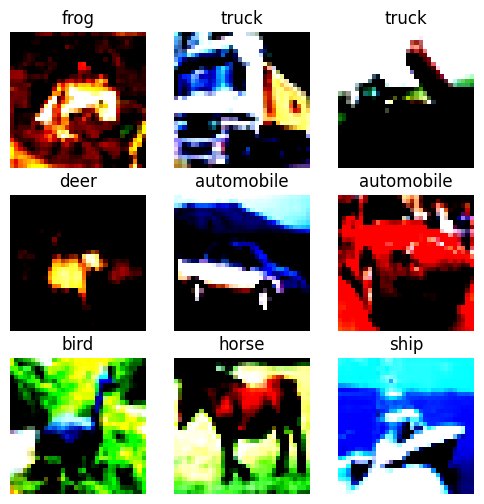

In [6]:
fig = plt.figure(figsize=(6, 6))
for i in range(9):
    img, label = train_dataset[i]
    plt.subplot(3, 3, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(train_dataset.classes[label])
    plt.axis('off')
    
plt.show()

In [7]:
img, lbl = train_dataset[0]
img.shape

torch.Size([3, 32, 32])

# Create Simple MLP Model

In [8]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.layer(x)

# Train Model Simply

In [8]:
model = MLP()
epochs = 30
criterion = nn.CrossEntropyLoss()
optim = torch.optim.Adam(model.parameters(), lr=0.002)

for epoch in range(epochs):
    train_loss = 0.0

    for image, label in train_loader:
        output = model(image)
        loss = criterion(output, label)

        optim.zero_grad()
        loss.backward()
        optim.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    print(f'Epoch: {epoch + 1}, train Loss: {avg_train_loss:.4f}')

Epoch: 1, train Loss: 1.7181
Epoch: 2, train Loss: 1.5327
Epoch: 3, train Loss: 1.4496
Epoch: 4, train Loss: 1.3874
Epoch: 5, train Loss: 1.3288
Epoch: 6, train Loss: 1.2717
Epoch: 7, train Loss: 1.2334
Epoch: 8, train Loss: 1.1863
Epoch: 9, train Loss: 1.1386
Epoch: 10, train Loss: 1.1004
Epoch: 11, train Loss: 1.0625
Epoch: 12, train Loss: 1.0297
Epoch: 13, train Loss: 0.9965
Epoch: 14, train Loss: 0.9651
Epoch: 15, train Loss: 0.9256
Epoch: 16, train Loss: 0.9011
Epoch: 17, train Loss: 0.8819
Epoch: 18, train Loss: 0.8488
Epoch: 19, train Loss: 0.8181
Epoch: 20, train Loss: 0.7999
Epoch: 21, train Loss: 0.7760
Epoch: 22, train Loss: 0.7624
Epoch: 23, train Loss: 0.7413
Epoch: 24, train Loss: 0.7266
Epoch: 25, train Loss: 0.7177
Epoch: 26, train Loss: 0.7113
Epoch: 27, train Loss: 0.6825
Epoch: 28, train Loss: 0.6560
Epoch: 29, train Loss: 0.6416
Epoch: 30, train Loss: 0.6257


# Add Validation Loss to Training Code

In [10]:
model = MLP()
epochs = 20
criterion = nn.CrossEntropyLoss()
optim = torch.optim.Adam(model.parameters(), lr=0.002)

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for image, label in train_loader:
        optim.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        optim.step()
        train_loss += loss.item()
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for image, label in val_loader:
            output = model(image)
            loss = criterion(output, label)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    avg_train_loss = train_loss / len(train_loader)
    
    print(f'Epoch: {epoch + 1}, train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}')

Epoch: 1, train Loss: 1.7214, Validation Loss: 1.4984
Epoch: 2, train Loss: 1.5398, Validation Loss: 1.4426
Epoch: 3, train Loss: 1.4447, Validation Loss: 1.3670
Epoch: 4, train Loss: 1.3795, Validation Loss: 1.2908
Epoch: 5, train Loss: 1.3245, Validation Loss: 1.2323
Epoch: 6, train Loss: 1.2697, Validation Loss: 1.1754
Epoch: 7, train Loss: 1.2188, Validation Loss: 1.1318
Epoch: 8, train Loss: 1.1724, Validation Loss: 1.0983
Epoch: 9, train Loss: 1.1274, Validation Loss: 1.0450
Epoch: 10, train Loss: 1.0993, Validation Loss: 0.9902
Epoch: 11, train Loss: 1.0558, Validation Loss: 0.9614
Epoch: 12, train Loss: 1.0169, Validation Loss: 0.9680
Epoch: 13, train Loss: 0.9929, Validation Loss: 0.8985
Epoch: 14, train Loss: 0.9545, Validation Loss: 0.8971
Epoch: 15, train Loss: 0.9236, Validation Loss: 0.8208
Epoch: 16, train Loss: 0.9026, Validation Loss: 0.7953
Epoch: 17, train Loss: 0.8612, Validation Loss: 0.7871
Epoch: 18, train Loss: 0.8537, Validation Loss: 0.7962
Epoch: 19, train Lo

# Test Loss and Accuracy

In [21]:
def test_model(model):
    acc = 0
    with torch.no_grad():
        model.eval()
        for image, label in test_loader:
            pred = model(image)
            acc += (pred.argmax(dim=1) == label).float().mean().item()
        
        accuracy = acc / len(test_loader)

    print(f"Accuracy on test set: {accuracy*100:.2f}%")

In [ ]:
test_model(model)

# Add Early stopping and L2 Regularization

In [ ]:
model = MLP()
criterion = nn.CrossEntropyLoss()
optim = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [34]:
def train_model(model, criterion, optim, scheduler=None, epochs=10, repeat=4):

    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for image, label in train_loader:
            optim.zero_grad()
            output = model(image)
            loss = criterion(output, label)
            loss.backward()
            optim.step()
            train_loss += loss.item()

            if scheduler:
                scheduler.step()
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for image, label in val_loader:
                output = model(image)
                loss = criterion(output, label)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        avg_train_loss = train_loss / len(train_loader)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model, './best_model_cifar.pth')
            wait = 0

        else:
            wait += 1
            if wait >= repeat:
                print(f'we have early stopping in epoch {epoch + 1}')
                break
        
        print(f'Epoch: {epoch + 1}, train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}')

In [22]:
test_model(model)

Accuracy on test set: 52.31%


# Add Batchnorm and Dropout

In [23]:
class RegularizationMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.layer(x)

In [ ]:
model = RegularizationMLP()
criterion = nn.CrossEntropyLoss()
optim = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-4)

In [30]:
train_model(model, criterion, optim, epochs=20, repeat=5)

Epoch: 1, train Loss: 1.0647, Validation Loss: 0.8067
Epoch: 2, train Loss: 1.0588, Validation Loss: 0.7975
Epoch: 3, train Loss: 1.0606, Validation Loss: 0.8180
Epoch: 4, train Loss: 1.0557, Validation Loss: 0.8245
Epoch: 5, train Loss: 1.0601, Validation Loss: 0.8135
Epoch: 6, train Loss: 1.0551, Validation Loss: 0.7943
Epoch: 7, train Loss: 1.0568, Validation Loss: 0.8000
Epoch: 8, train Loss: 1.0548, Validation Loss: 0.7815
Epoch: 9, train Loss: 1.0468, Validation Loss: 0.7850
Epoch: 10, train Loss: 1.0462, Validation Loss: 0.7825
Epoch: 11, train Loss: 1.0444, Validation Loss: 0.7584
Epoch: 12, train Loss: 1.0478, Validation Loss: 0.7669
Epoch: 13, train Loss: 1.0477, Validation Loss: 0.7827
Epoch: 14, train Loss: 1.0439, Validation Loss: 0.7743
Epoch: 15, train Loss: 1.0471, Validation Loss: 0.7831
we have early stopping in epoch 16


In [31]:
test_model(model)

Accuracy on test set: 56.65%


# Add scheduler on training

In [42]:
model = RegularizationMLP()
criterion = nn.CrossEntropyLoss()
optim = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=5, gamma=0.2)

In [43]:
train_model(model, criterion, optim, scheduler, 40, repeat=5)

Epoch: 1, train Loss: 2.1729, Validation Loss: 2.1248
Epoch: 2, train Loss: 2.1675, Validation Loss: 2.1254
Epoch: 3, train Loss: 2.1701, Validation Loss: 2.1253
Epoch: 4, train Loss: 2.1678, Validation Loss: 2.1272
Epoch: 5, train Loss: 2.1702, Validation Loss: 2.1261
we have early stopping in epoch 6


In [41]:
test_model(model)

Accuracy on test set: 27.36%
